# The Bose-Einstein Condensate

# Preface: The 2001 Nobel Prize in Physics and the Bose-Einstein Condensate
In 2001, the Nobel Prize in Physics was awarded jointly to Eric A. Cornell, Wolfgang Ketterle, and Carl E. Wieman.<sup>[1](#ref-1)</sup> 
They were recognized for their groundbreaking achievement: the creation of a Bose-Einstein Condensate (BEC) in dilute gases of alkali atoms. 
A BEC represents a macroscopic quantum state of matter, initially predicted by Satyendra Nath Bose and Albert Einstein in 1924–1925.<sup>[2](#ref-2)</sup>

The pioneering experiment by Cornell and Wieman in 1995 utilized a dilute gas of rubidium-87 ($^{87}\text{Rb}$) atoms. 
An atom of $^{87}\text{Rb}$ contains $37$ electrons, $37$ protons, and $50$ neutrons, totaling $124$ fundamental fermions. 
Because the composite particle comprises an even number of fermions, $^{87}\text{Rb}$ behaves as an integer-spin boson and obeys Bose-Einstein statistics. 
Without constraint from the Pauli exclusion principle, the atoms are free to undergo a phase transition wherein a macroscopic fraction of the ensemble condenses into the single-particle ground state at sufficiently low temperatures.

To achieve condensation, the atoms had to be cooled to extreme temperatures—typically below $200 \text{nK}$. 
This was accomplished via laser cooling followed by forced evaporative cooling in a magnetic trap.<sup>[1](#ref-1)</sup> 
The phase transition occurs when the thermal de Broglie wavelength of the atoms becomes comparable to the mean interparticle spacing, causing their matter waves to overlap and merge into a single, coherent macroscopic quantum state.

<span id="fig-1"></span>![Velocity-distribution data of a gas of rubidium atoms, confirming the discovery of a new phase of matter, the Bose-Einstein condensate.](BEC_NOBEL.jpeg)

*Figure 1. Successive occurrence of Bose-Einstein condensation in rubidium. From left to right is shown the atomic distribution in the cloud just prior to condensation, at the start of condensation and after full condensation. High peaks correspond to a large number of atoms. Silhouettes of the expanding atom cloud were recorded 6 ms after switching off the confining forces of the atom trap. (Taken from [1](#ref-1)).*

The key observable that confirmed the presence of a BEC was the velocity distribution of the atoms ([Fig. 1](#fig-1)). 
As seen in the middle or right-most plots, after $6\text{ ms}$ of free expansion, the majority of the particles remained concentrated in the center rather than dispersing outward. 
Because this expansion maps positions directly to the initial velocity/momentum distribution ($\mathbf{r}(t) = \mathbf{v}*t$), the sharp central peak indicates that the majority of particles occupy the same $|\mathbf{v}| = |\mathbf{q}| = 0$ state - that is, they macroscopically occupy the ground state.

# Modeling Superfluidity: The Attractive Hubbard Model
In this notebook, we simulate the **attractive Hubbard model on a 2D square lattice** using [pyALF](https://github.com/ALF-QMC/pyALF). 
While the original BEC experiments studied non-interacting (or weakly interacting) dilute atomic gases, similar macroscopic quantum phenomena occur in strongly interacting systems, such as the condensation of electron pairs in superconductors.
We compute the $s$-wave pair correlation function across varying system sizes and temperatures to observe the onset of macroscopic coherence.
Instead of a microcanonical ensemble of atoms in a trap, we use a grand canonical ensemble for computational simplicity. 
We fix the chemical potential ($\mu$), which allows the particle number to fluctuate as we vary the temperature ($T=1/\beta$). 
To ensure our results remain comparable to standard BEC experiments, we must carefully monitor the average particle density. 
As long as this density remains approximately constant, we can confidently draw parallels between our measurment and the original **BEC** experiment.<sup>[1](#ref-1)</sup> 

## The model and its transition

The Hamiltonian for our system is given by:

$$
\hat H=-t\sum_{\langle i,j\rangle,\sigma}
\left(\hat c^\dagger_{i\sigma}\hat c_{j\sigma}+\mathrm{h.c.}\right)
+U\sum_i\left(\hat n_{i\uparrow}-\frac12\right)
\left(\hat n_{i\downarrow}-\frac12\right)
-\mu\sum_{i,\sigma}\hat n_{i\sigma},\qquad U<0.
$$

* **Kinetic Energy (Hopping):** The first term describes the kinetic energy, where electrons hop between nearest-neighbor sites $i$ and $j$ with an amplitude $t$.
* **Interaction Energy:** The second term describes the on-site Hubbard interaction. Because we choose $U < 0$, the interaction is attractive. This favors putting two electrons (with opposite spins, to satisfy Pauli exclusion) on the same lattice site.
* **Chemical Potential:** The third term controls the average density of the system via the chemical potential $\mu$.


## Connection to BEC

Why does a model of interacting fermions (electrons) relate to the physics of bosons? 
The attractive interaction ($U < 0$) favors the formation of local spin-singlet electron pairs.
 Depending on the interaction strength, this model elegantly captures the **BCS–BEC crossover**. 
 At weak coupling, the system forms large, overlapping Cooper pairs (BCS regime). 
 As the attraction grows ($|U|/t \gg 1$), they evolve smoothly into tightly bound, local pairs that effectively behave as composite bosons (BEC regime). 

It is crucial to distinguish between pair formation and collective phase coherence. 
In strongly interacting systems, fermions can bind into pairs at higher temperatures without immediately exhibiting coherent superfluid behavior. 
Because this notebook scans temperature at a fixed interaction strength, we are observing the onset of this macroscopic phase coherence rather than mapping out the interaction-driven crossover BCS-BEC crossover.

Furthermore, because our model is two-dimensional, it does not undergo a standard continuous phase transition to a state with true long-range order. 
Instead, away from half-filling (which we ensure by setting $\mu = 0.5$), the finite-temperature superfluid transition is a **Berezinskii–Kosterlitz–Thouless (BKT) transition**. 
Below the BKT transition temperature, vortex–antivortex pairs are bound, and pair correlations exhibit quasi-long-range order (decaying algebraically). 
Above it, unbinding vortices proliferate and destroy this topological order. 

*(Note: Because BKT transitions exhibit subtle finite-size scaling, the short QMC runs and small lattice sizes used in this demonstration are meant primarily to illustrate how to measure pairing correlations. Their curves alone cannot rigorously establish the exact thermodynamic transition temperature $T_{BKT}$.)*



# Simulating with pyALF
## Import the tools

`Simulation` prepares and runs ALF, `ALF_source` manages its source checkout, and `load_res` reads the analysed results. `Lattice` maps physical momenta to array indices; `NumPy`, `pandas` organise the data, and `Matplotlib` makes the plots.

The plotting setup uses `scienceplots` for styling and `%matplotlib widget` for interactive figures, which requires `ipympl` in the notebook environment. 
The `science` style also enables LaTeX rendering by default. 
If those optional plotting dependencies are unavailable, a standard Matplotlib style and inline backend can be used instead. 
The ALF build requirements are described in the [installation section](../02-installation.md).

In [1]:
from py_alf import Simulation, ALF_source, Lattice
from py_alf.ana import load_res  # Function for loading analysis results
from py_alf.utils import find_sim_dirs  # Function for finding QMC bins

#Data management
import numpy as np  
import pandas as pd

#utils
from pathlib import Path
from collections import defaultdict

#Plots
import matplotlib.pyplot as plt  # Plotting library
%matplotlib widget
import scienceplots
plt.style.use('science')

## Set the ALF source directory

The notebook expects the `ALF` directory in the notebook's working directory. If it is not present it will automatically download it. `ALF_source` manages this checkout, and the returned `alf_dir` object is passed to every simulation.

**Required observable:** this tutorial depends on an ALF extension that measures the $s$-wave pair correlation function, named `Pair`. 
The Python analysis stores its momentum-space results under in `res.pkl` under `Pair_eqK` and `Pair_eqK_err`, and in the `res`directory in the file`Pair_eq_K`.


In [2]:
alf_dir = ALF_source(alf_dir=str(Path.cwd() / 'ALF'), branch="s-wave-Pairing_correlations")

Checking out branch s-wave-Pairing_correlations
Your branch is up to date with 'origin/s-wave-Pairing_correlations'.


Already on 's-wave-Pairing_correlations'


## Compile ALF

Create a Hubbard `Simulation` object and compile the executable once. Compilation prepares the program; it does not yet run the Monte Carlo calculation. The same executable is reused for every temperature and lattice size, hence no recompilation is needed in this notebook.

In [3]:
compile_sim = Simulation(alf_src=alf_dir, ham_name='Hubbard',sim_dict={}) #sim_dict is used to choose parameters.
compile_sim.compile()

Checking out branch s-wave-Pairing_correlations
Your branch is up to date with 'origin/s-wave-Pairing_correlations'.


Already on 's-wave-Pairing_correlations'


Compiling ALF... 
Cleaning up Prog/
Cleaning up Libraries/
Cleaning up Analysis/
Compiling Libraries


entanglement_mod.F90:35:2:

   35 | #warning "You are compiling entanglement without MPI. No Renyi entropy results possible, all other observables still work!"
      |  1~~~~~~
ar: creating archive modules_90.a
ar: creating archive libqrref.a


Compiling Analysis
Compiling Program
Compiling program modules
Parsing Hamiltonian parameters
filenames: Hamiltonians/Hamiltonian_Kondo_smod.F90 Hamiltonians/Hamiltonian_Kondo_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_Hubbard_smod.F90 Hamiltonians/Hamiltonian_Hubbard_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_Hubbard_Plain_Vanilla_smod.F90 Hamiltonians/Hamiltonian_Hubbard_Plain_Vanilla_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_tV_smod.F90 Hamiltonians/Hamiltonian_tV_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_LRC_smod.F90 Hamiltonians/Hamiltonian_LRC_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_Z2_Matter_smod.F90 Hamiltonians/Hamiltonian_Z2_Matter_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_Spin_Peierls_smod.F90 Hamiltonians/Hamiltonian_Spin_Peierls_read_write_parameters.F90
Link program
Done.


## Run the simulations

We simulate periodic square lattices with $L=4,6,8$, containing $N_s=L^2=16,36,64$ sites, where the inverse temperatures takes values $\beta t=1,2,\ldots,7$, thus yielding 21 independent Simulations in total.
Objects of class `Simulation` carry a `sim_dict`, usually of type python `dict`, that contains all changes of parameters to specified default parameters.

The following gives a brief overview over the used parameters for this simulation. 
Read more about them in the official `ALF` documentation.<sup>[3](#ref-3)</sup>
| Parameter | Meaning in this example |
| --- | --- |
| `Lattice_type`, `L1`, `L2` | Square geometry with $L_1\times L_2$ sites and one orbital per unit cell. |
| `ham_U=-4.0` | On-site attraction of magnitude $4t$. |
| `ham_chem=0.5` | Fixed chemical potential; the particle density may vary with temperature and size. |
| `Beta` | Inverse temperature $\beta=1/T$.|
| `Nsweep`, `NBin` | Number of Monte Carlo sweeps per bin and Number of bins per simulation. |
| `Mz=True` | A Hubbard–Stratonovich decomposition in the spin-density channel.  |
| `N_SUN=2`, `N_FL=2` | The physical spin-$\tfrac12$ model. In this two-flavour Hubbard setup, ALF internally halves `N_SUN`, leaving one colour for each spin flavour. |
| `Checkerboard`, `Symm` | A symmetric checkerboard decomposition of imaginary-time evolution; finite-time-step errors remain to be checked. |
| `Ltau=0` | Measure equal-time observables only, which suffice for the pair structure factor. |

For each $(L,\beta)$, `sim.run()` performs the simulation and `sim.analysis()` estimates means and statistical errors. Results are stored separately by size and inverse temperature. Existing run directories can be resumed, so the saved statistics may include earlier runs as well as the requested new bins.


In [4]:
LAT_SIZES = [4, 6, 8]
BETAS = [i for i in range(1,8)]

for beta in BETAS:
    for L in LAT_SIZES:
        sim = Simulation(
                    alf_dir, 'Hubbard',
                    sim_dict={
                        ### Choice of Predefined Model###
                        'Model': 'Hubbard',
                        
                        ###Definition of the Lattice###
                        'Lattice_type': 'Square',
                        'L1': L,
                        'L2': L,
                        
                        #--- Model parameters ---#
                        'Beta': float(beta),
                        'ham_chem': 0.5,
                        'ham_U': -4.0,
                        #--- Simulation parameters --- #
                        'Nsweep': 10,
                        'NBin': 10,
                        'Mz': True, #Choice of HS-Transformation (Exclusive for Hubbard-type interactions); ALF-DOC: 8.3.2 M_Z-Hubbard interaction
                        'Checkerboard': True, #ALF-DOC: 2.3. The Trotter error and checkerboard decomposition
                        'Symm': True, #Symmetric Trotter decomposition; ALF-DOC: 2.3. The Trotter error and checkerboard decomposition

                        ###ALF Internal Flags###
                        'N_SUN': 2, #
                        'N_FL': 2, # 
                        'Ltau': 0, #Speed up simulation by not calculating time-displaced observables, which take more time to compute.
                    },
                    machine='GNU',
                    sim_dir=f'Attractive_Hubbard_L{L}_beta_{beta}'
                )
        
        sim.run() #Running the simulation
        sim.analysis() #Analysing the data
        
print('Done! :)')

Prepare directory "/Users/luis/Documents/_WORK/CONFERENCES/ALF_WORKSHOP/ALF_Tutorial/jupyterbook/source/04-nice-physics/ALF_data/Attractive_Hubbard_L4_beta_1" for Monte Carlo run.
Create new directory.
Run /Users/luis/Documents/_WORK/CONFERENCES/ALF_WORKSHOP/ALF_Tutorial/jupyterbook/source/04-nice-physics/ALF/Prog/ALF.out
 ALF Copyright (C) 2016 - 2022 The ALF project contributors
 This Program comes with ABSOLUTELY NO WARRANTY; for details see license.GPL
 This is free software, and you are welcome to redistribute it under certain conditions.
 No initial configuration
### Analyzing /Users/luis/Documents/_WORK/CONFERENCES/ALF_WORKSHOP/ALF_Tutorial/jupyterbook/source/04-nice-physics/ALF_data/Attractive_Hubbard_L4_beta_1 ###
/Users/luis/Documents/_WORK/CONFERENCES/ALF_WORKSHOP/ALF_Tutorial/jupyterbook/source/04-nice-physics
Scalar observables:
Ener_scal
Kin_scal
Part_scal
Pot_scal
Histogram observables:
Equal time observables:
Den_eq
Green_eq
Pair_eq
SpinT_eq
SpinXY_eq
SpinZ_eq
Time disp

## Load the analysed observables

`find_sim_dirs()` discovers simulation directories and `load_res(dirs)` collects their analysed results into a pandas table, with one row per run. 
Restrict `dirs` to this temperature scan if the working directory also contains runs from the Mott notebook or other examples.

The analysis below reads:

- `Pair_eqK` and `Pair_eqK_err`: the $s$-wave pair correlations in momentum space and its statistical error.
- `Pair_eq_lattice`: the geometry needed to locate a momentum in the stored arrays.
- `Part_scal0` and `Part_scal0_err`: the total particle number and its error in the standard Hubbard measurement.
- `l1` and `beta`: the lattice size in $x$ direction and inverse temperature identifying each result.

The suffix `eq` denotes equal imaginary time, while `K` denotes momentum space. 
An equal-time structure factor is different from a pair susceptibility, which also involves an imaginary-time integral.


In [5]:
dirs = find_sim_dirs()
res=load_res(dirs)

./ALF_data/Attractive_Hubbard_L4_beta_1
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L4_beta_2
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L4_beta_3
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L4_beta_4
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L4_beta_5
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L4_beta_6
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L4_beta_7
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L6_beta_1
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L6_beta_2
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L6_beta_3
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L6_beta_4
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L6_beta_5
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L6_beta_6
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L6_beta_7
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L8_beta_1
No orbit

## Extract the pair structure factor

Define the on-site spin-singlet pair operators

$$
\hat b_i^\dagger=\hat c_{i\uparrow}^\dagger\hat c_{i\downarrow}^\dagger,
\qquad
\hat b_i=\hat c_{i\downarrow}\hat c_{i\uparrow}.
$$

The correlator $\langle\hat b_i^\dagger\hat b_j\rangle$ measures coherence between pairs at different sites. 
The on-site orbital structure is invariant under lattice rotations, giving this pairing channel its $s$-wave character.
We use the structure-factor convention

$$
N(\mathbf q)=\frac{1}{N_s}\sum_{i,j}
e^{i\mathbf q\cdot(\mathbf r_i-\mathbf r_j)}
\langle\hat b_i^\dagger\hat b_j\rangle.
$$

Uniform pairing is detected at $\mathbf q=(0,0)$, where contributions from distant sites add without a relative phase. Even incoherent local pairs contribute to $N(0)$: the terms with $i=j$ are the double occupancy $\langle\hat n_{i\uparrow}\hat n_{i\downarrow}\rangle$. 
A nonzero value alone therefore does not establish superfluidity. One needs to proof that $\lim_{N_\text{particle}\to \infty}\frac{\braket{N(q=(0,0))}}{N_\text{particle}} > 0$.
This extrapolation is left as exercise for the reader. Notice, that $N_\text{particle}$ is the number of particles in the system.

We first define a function `extract_pair_at_q` that extracts the $s$-wave pair correlation for a specified momentum $q$. 
It uses `pyALF`'s internal `Lattice.k_to_n` function to locate the index of the entry with the requested momentum.
The square lattice has one site per unit cell, so `np.squeeze` removes the redundant orbital axes and leaves one value and error per run. 
The function groups these data, together with the particle number and inverse temperature, by lattice size.

In [6]:
def extract_pair_at_q(q: tuple, res: pd.DataFrame):
    '''
    ...#TODO
    '''
    plot_data = defaultdict(lambda: defaultdict(list))
    for idx in range(len(res)):
        latt = Lattice(res.iloc[idx]["Pair_eq_lattice"]) 
        q_idx = latt.k_to_n(q)
        pair_eq_k = np.squeeze(res.iloc[idx]["Pair_eqK"][...,q_idx])
        pair_eq_k_err = np.squeeze(res.iloc[idx]["Pair_eqK_err"][...,q_idx])
        L = res.iloc[idx]["l1"]
        beta = res.iloc[idx]["beta"]
        part_num_val = res.iloc[idx]["Part_scal0"]
        part_num_err = res.iloc[idx]["Part_scal0_err"]

        plot_data[f"L_{L}"]["beta"].append(beta)
        plot_data[f"L_{L}"]["pair_value"].append(pair_eq_k)
        plot_data[f"L_{L}"]["pair_err"].append(pair_eq_k_err)        
        plot_data[f"L_{L}"]["part_num_value"].append(part_num_val/(L**2))
        plot_data[f"L_{L}"]["part_num_err"].append(part_num_err/(L**2))
    return plot_data

We then evaluate the helper at $\mathbf q=(0,0)$ to obtain the $N(q=(0,0))$ $s$-wave paring correlation for each $(L,\beta)$.

In [7]:
plot_data = extract_pair_at_q((0,0), res)

## Plot the pairing correlations

Convert each inverse temperature to $T=1/\beta$ and plot $N(0)$ with statistical error bars. Since $t=1$, the horizontal axis is numerically $T/t$. Cooling moves from right to left on this plot. Growth upon cooling and an increasing dependence on $L$ are signs that pair correlations extend over larger distances; their interpretation requires the previously discussed extrapolation to thermodynamic limit.

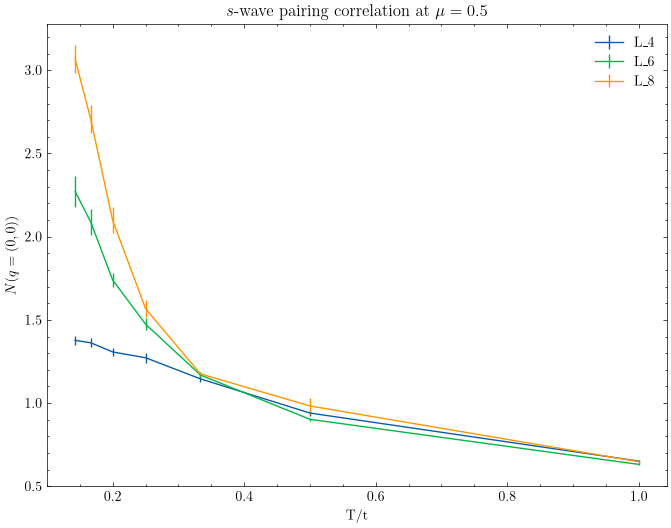

In [8]:
plt.close("all")
plt.figure(figsize=(8,6))
for L_key in plot_data.keys():
    T = [1/beta for beta in plot_data[L_key]["beta"]]
    data = plot_data[L_key]["pair_value"]
    err = plot_data[L_key]["pair_err"]
    plt.errorbar(T, data, yerr=err, label=L_key)
plt.title(r"$s$-wave pairing correlation at $\mu = 0.5$")
plt.xlabel(r"T/t")
plt.ylabel(r"$N(q=(0,0))$")
plt.legend()
plt.show()

## Monitor the particle number

At fixed chemical potential, the particle number can change as the system is cooled. The second plot tracks this change and helps determine the filling at which the pairing correlations were measured.

The standard ALF Hubbard observable `Part_scal` is the **total** particle number and stored under the key `Part_scal0` and `Part_scal0_err`in the `pandas.DataFrame`.

$$
N_e=\sum_{i,\sigma}\langle\hat n_{i\sigma}\rangle.
$$

To compare fillings across lattice sizes, we use the density per site $n=N_e/L^2$, with error $\delta n=\delta N_e/L^2$. 
Then $0\leq n\leq2$, and half filling is $n=1$.


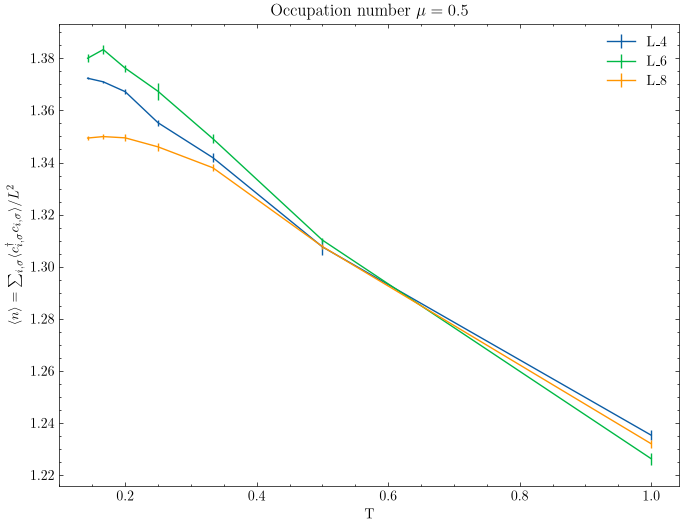

In [9]:
plt.close("all")
plt.figure(figsize=(8,6))
for L_key in plot_data.keys():
    data = plot_data[L_key]["part_num_value"]
    err = plot_data[L_key]["part_num_err"]
    plt.errorbar(T, data, yerr=err, label=L_key)
    plt.title(r"Occupation number $\mu = 0.5$")
    plt.xlabel(r"T")
    plt.ylabel(r"$\langle n \rangle = \sum_{i,\sigma} \langle c^\dagger_{i,\sigma} c_{i,\sigma} \rangle/L^2$")
plt.legend()
plt.show()

The filling varies from $\approx 1.2$ to $\approx 1.4$, a proper comparison with the 2001 Nobel-prize does require to fix the particle number, but the workload this requires, is too large for this introductory example.
We still recreate the famous [Fig. 1](#fig-1) anyway.

## Comparison to the 2001 Nobel Prize in Physics
`pyALF`not only provides the binary `res.pkl` file, which we implicitly utilized previously for plotting by loading it via `load_res()`. 
The analyzed observables are also stored in a readable format in `ALF_data/<sim_dir>/res/<observable>`.

### Load Meta Data from res.pkl
We first define a helper function `load_meta`, that returns the metadata ( $L_1, L_2, \beta, \mu, ...$) of a specific simulation.
We will need to pass to this function the `res` object of class `pandas.DataFrame`, that we earlier loaded via the `load_res` function of `pyALF`.
From `res` we extract the metadata for a specific simulation, which we need to specify via the `path` variable.

In [10]:
def load_meta(path: str, res: pd.DataFrame) -> dict:
    '''
    Takes a sim_dir.
    Returns a dictionary, containing:
    Lattice size, beta, chemical potential, and all other metadata for that path.
    '''

    row = res.loc[path]
    
    # Convert the pandas Series to a standard Python dictionary
    meta_dict = row.to_dict()
    
    return meta_dict

The metadata is conveniently stored in a python `dict`.
We therefore can make use of the `keys()`function, to get an overview of what is stored inside.

In [11]:
temp_meta = load_meta(res.index[0],res)
print(type(temp_meta))

print(temp_meta.keys())
print("\nL1: ", temp_meta['l1'])
print("L2: ", temp_meta['l2'])
print("Beta: ", temp_meta['beta'])


<class 'dict'>
dict_keys(['continuous', 'ham_chem', 'ham_h0', 'ham_t', 'ham_t2', 'ham_tperp', 'ham_u', 'ham_u2', 'mz', 'l1', 'l2', 'lattice_type', 'model', 'beta', 'bulk', 'checkerboard', 'dtau', 'n_fl', 'n_phi', 'n_sun', 'phi_x', 'phi_y', 'projector', 'symm', 'theta', 'Ener_scal_sign', 'Ener_scal_sign_err', 'Ener_scal0', 'Ener_scal0_err', 'Kin_scal_sign', 'Kin_scal_sign_err', 'Kin_scal0', 'Kin_scal0_err', 'Part_scal_sign', 'Part_scal_sign_err', 'Part_scal0', 'Part_scal0_err', 'Pot_scal_sign', 'Pot_scal_sign_err', 'Pot_scal0', 'Pot_scal0_err', 'Den_eqK', 'Den_eqK_err', 'Den_eqK_sum', 'Den_eqK_sum_err', 'Den_eqR', 'Den_eqR_err', 'Den_eqR_sum', 'Den_eqR_sum_err', 'Den_eq_lattice', 'Green_eqK', 'Green_eqK_err', 'Green_eqK_sum', 'Green_eqK_sum_err', 'Green_eqR', 'Green_eqR_err', 'Green_eqR_sum', 'Green_eqR_sum_err', 'Green_eq_lattice', 'Pair_eqK', 'Pair_eqK_err', 'Pair_eqK_sum', 'Pair_eqK_sum_err', 'Pair_eqR', 'Pair_eqR_err', 'Pair_eqR_sum', 'Pair_eqR_sum_err', 'Pair_eq_lattice', 'SpinT_eq

We then write a function `load_pair_from_path`.
The analysed pair-correlation data are also available as a plain-text file named `Pair_eq_K` inside each simulation directory. The helper below loads this file directly rather than reading the observable from the `res` DataFrame.

The function first searches the supplied simulation directory recursively for `Pair_eq_K` and checks that exactly one matching file is found. 
It then skips the file header and loads the numerical data with `numpy.loadtxt`. 
The first two relevant columns contain the momentum coordinates, $k_x$ and $k_y$, while the final column contains the corresponding pair-correlation value $N(\mathbf{k})$.
We assume the data to be good enough for the visualization as $3d$ plot without its error.

The rows in the file are not assumed to be arranged in the order required for plotting. We therefore sort them lexicographically by $k_y$ and then by $k_x$. 
Since the data describe a rectangular momentum grid, the number of unique $k_x$ and $k_y$ values determines the two-dimensional array shape; `set` is used to filter all unique elements in the `numpy.arrays`.
Finally, the sorted coordinates and correlation values are reshaped into three arrays, returned as the tuple `(X, Y, Z)`. 
These arrays can be passed directly to plotting functions such as `matplotlib.pyplot.plot_surface`.

In [12]:
def load_pair_from_path(path: str):
    path = Path(path)
    matches = list(path.rglob("Pair_eq_K"))
    if len(matches) != 1: raise ValueError(f"Expected exactly 1 file, found {len(matches)}")
    
    d = np.loadtxt(matches[0], skiprows=1)[:, :-3]
    x, y, z = d[:, 0], d[:, 1], d[:, -1]
    
    shape = (len(set(y)), len(set(x)))
    return tuple(v[np.lexsort((x, y))].reshape(shape) for v in (x, y, z))

In [13]:
def plot_3d(path: str, res: pd.DataFrame):
    X,Y,Z = load_pair_from_path(path)
    meta = load_meta(path,res)
    fig, ax = plt.subplots(figsize=(6, 5),subplot_kw={"projection": "3d"})
    ax.set_box_aspect([1, 1, 0.65])
    
    ax.plot_surface(
    X, Y, Z,
    cmap="rainbow",
    vmin=0,
    vmax=1.5,
    alpha=0.80,
    edgecolor="white",
    linewidth=0.5,
    )
    title_text = (
        f"On-site pair correlator $N(q)$\n"
        f"for {meta['l1']}$\\times${meta['l2']} square lattice; "
        f"$\\mu = {meta['ham_chem']}$, $\\beta = {meta['beta']}$"
    )
    ax.set_zlim((0,3.0))
    
    ax.set(title=title_text, xlabel=r"$k_x$", ylabel=r"$k_y$", zlabel=r"$N(q)$")
    ax.grid(True)

    plt.tight_layout()
    plt.show()

We manually plot the results for three simulations, to recreate [Fig. 1](#fig-1). 

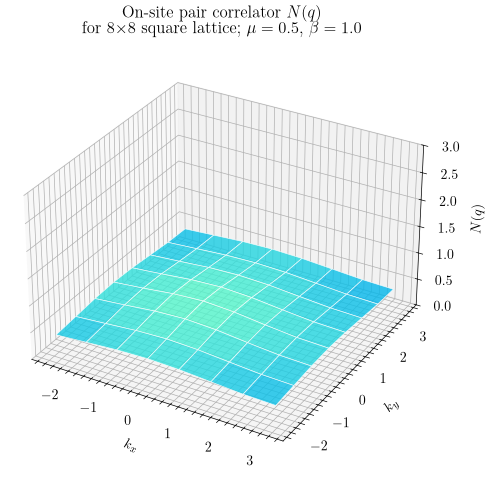

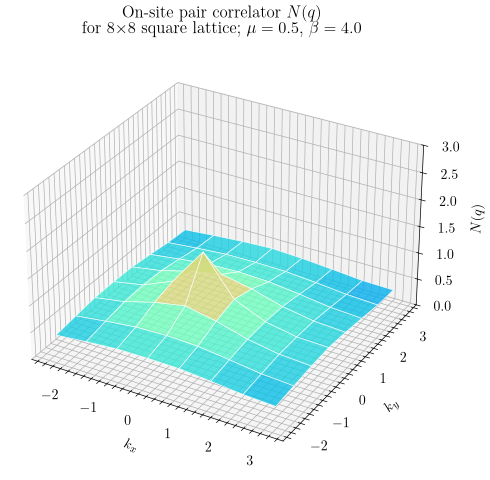

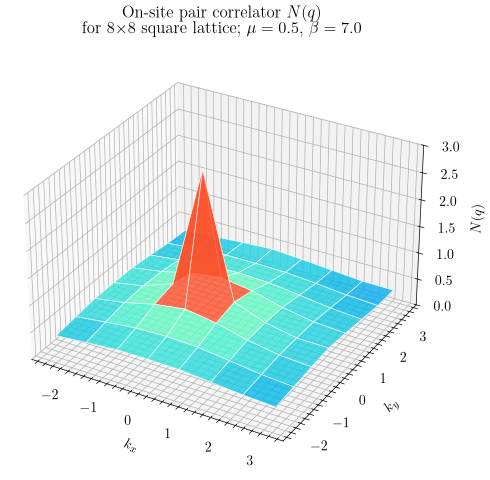

In [14]:
plt.close("all")
paths = [
    './ALF_data/Attractive_Hubbard_L8_beta_1', 
    './ALF_data/Attractive_Hubbard_L8_beta_4', 
    './ALF_data/Attractive_Hubbard_L8_beta_7'
]
for p in paths:
    plot_3d(p, res)

This concludes the comparison to the **BEC**. If this was your first ever *AFQMC* simulation, congratulations and welcome to the `ALF-club`!

### Sources

<div id="ref-1">
[1] Nobel Prize Outreach AB. (2001). <i>The 2001 Nobel Prize in Physics - Popular Information</i>. <a href="https://www.nobelprize.org/prizes/physics/2001/popular-information/">https://www.nobelprize.org/prizes/physics/2001/popular-information/</a>
</div>

<div id="ref-2">
[2] Einstein, A. (1924). Quantentheorie des idealen Gases. <i>Sitzungsberichte der Preussischen Akademie der Wissenschaften, Physikalisch-Mathematische Klasse</i>, 1924, 261–267.
</div>

<div id="ref-3">
[3] ALF Collaboration (2025). The ALF (Algorithms for Lattice Fermions) project release 2.4: Documentation for the auxiliary-field quantum Monte Carlo code. <i>SciPost Phys. Codebases</i>, 1-v2.4, 4. Available at: <a href="https://alf.physik.uni-wuerzburg.de/page/documentation">https://alf.physik.uni-wuerzburg.de/page/documentation</a>.
</div>